# Chunking Passes for Jackknives

The question is how to chunk data into as short temporal sequences as possible, while hitting a balance between sparse beam samples and being stupidly empty. All while decimating the passes by a factor of 5, to eliminate the worst of the correlation introduced by the SavGol filtering

In [1]:
from pathlib import Path
from datetime import datetime, UTC
from collections.abc import Sequence

import numpy as np
import healpy as hp
import cmasher as cmr
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.colors import ListedColormap

from embers_passes import PassFile

colors = cmr.pride(np.linspace(0.1, 0.8, 256))
colors[0] = mcolors.to_rgba("whitesmoke")
prd = ListedColormap(colors, name="pride")
prd.set_under("whitesmoke")

In [2]:
def chunk_passes(
    passes: list,
    chunk_sec: float,
) -> tuple[list[list[int]], np.ndarray, np.ndarray]:
    """Group pass indices into fixed-duration time chunks.

    The first time bin begins at the earliest ``unix_time`` in ``passes``.
    Passes are assigned to consecutive bins of width ``chunk_sec``.

    Parameters
    ----------
    passes
        List of pass records. Each record must contain ``unix_time`` attributes.
    chunk_sec
        Width of each time bin in seconds. Must be positive.

    Returns
    -------
    chunks
        Nested list of pass indices. Each inner list contains the indices of
        passes belonging to the corresponding time bin.
    bin_edges
        Unix timestamps defining the edges of the time bins. Has length
        ``len(chunks) + 1``.
    bin_centers
        Unix timestamps at the centers of the time bins. Has length
        ``len(chunks)``.
    """
    if chunk_sec <= 0:
        raise ValueError("chunk_sec must be positive.")

    if len(passes) == 0:
        return [], np.array([], dtype=float), np.array([], dtype=float)

    unix_times = np.asarray(
        [pass_record.unix_time for pass_record in passes],
        dtype=float,
    )

    if not np.all(np.isfinite(unix_times)):
        raise ValueError("All pass unix_time values must be finite.")

    start_time = unix_times.min()

    chunk_indices = np.floor(
        (unix_times - start_time) / chunk_sec
    ).astype(int)

    n_chunks = int(chunk_indices.max()) + 1

    bin_edges = start_time + np.arange(n_chunks + 1) * chunk_sec
    bin_centers = bin_edges[:-1] + 0.5 * chunk_sec

    chunks: list[list[int]] = [[] for _ in range(n_chunks)]

    for pass_index, chunk_index in enumerate(chunk_indices):
        pass_record = passes[pass_index]

        chunks[chunk_index].append(pass_index)

    return chunks, bin_edges, bin_centers

In [3]:
def chunks_to_healpix_counts(
    passes,
    chunks: list[list[int]],
    decimate: int = 5,
    flag_threshold_db: float = 3.0,
    nside: int = 32,
) -> list[np.ndarray]:
    """Count pass samples in each HEALPix pixel for every time chunk.

    Each element of ``chunks`` contains indices selecting pass records from
    ``passes``. A separate HEALPix count map is constructed for each chunk.

    Passes whose maximum finite power exceeds ``flag_threshold_db`` are
    rejected and do not contribute any samples to the count map.

    Parameters
    ----------
    passes
        Sequence of pass records. Each record must provide ``alt_deg``,
        ``az_deg``, and ``power_db`` attributes.
    chunks
        Nested list of indices into ``passes``. Each inner list defines one
        time chunk.
    decimate
        Keep every Nth sample, 1 keeps all samples. Defaults to 5
    flag_threshold_db
        Reject a pass if its maximum finite power is greater than this
        threshold, in dB. Default is 3 dB.
    nside
        HEALPix NSIDE parameter. Default is 32.
    Returns
    -------
    count_maps
        List containing one HEALPix count map per chunk. Each map has shape
        ``(hp.nside2npix(nside),)`` and records the number of valid samples
        contributing to each pixel.
    """
    if not hp.isnsideok(nside):
        raise ValueError(f"Invalid HEALPix NSIDE: {nside}.")

    if decimate < 1:
        raise ValueError("decimate must be >= 1.")

    npix = hp.nside2npix(nside)
    count_maps: list[np.ndarray] = []

    for chunk in chunks:
        counts = np.zeros(npix, dtype=int)

        for pass_index in chunk:
            pass_record = passes[pass_index]
            alt_deg = np.asarray(pass_record.alt_deg, dtype=float)
            az_deg = np.asarray(pass_record.az_deg, dtype=float)
            power_db = np.asarray(pass_record.power_db, dtype=float)

            finite_power = np.isfinite(power_db)

            if not np.any(finite_power):
                continue

            if np.max(power_db[finite_power]) > flag_threshold_db:
                continue

            valid = (
                np.isfinite(alt_deg)
                & np.isfinite(az_deg)
                & finite_power
            )

            if not np.any(valid):
                continue

            alt_deg = alt_deg[valid]
            az_deg = az_deg[valid]

            if decimate > 1:
                alt_deg = alt_deg[::decimate]
                az_deg = az_deg[::decimate]

            theta = np.radians(90.0 - alt_deg)
            phi = np.radians(az_deg)

            pixels = hp.ang2pix(
                nside,
                theta,
                phi,
            )

            np.add.at(counts, pixels, 1)

        count_maps.append(counts)

    return count_maps

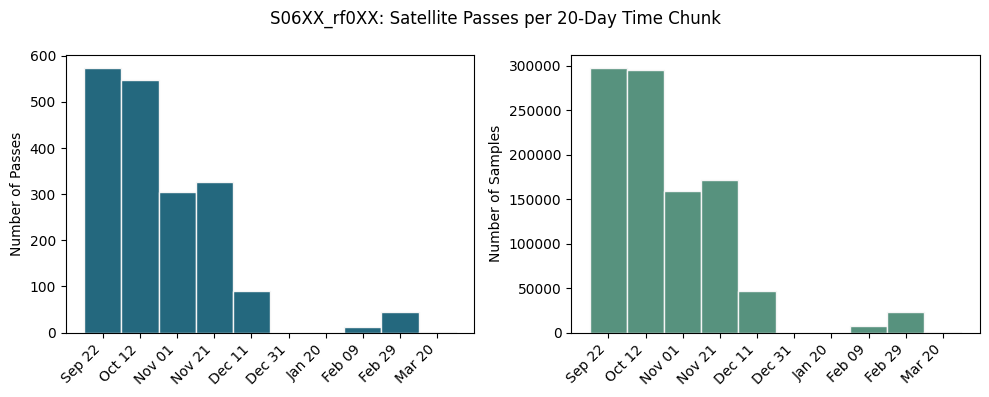

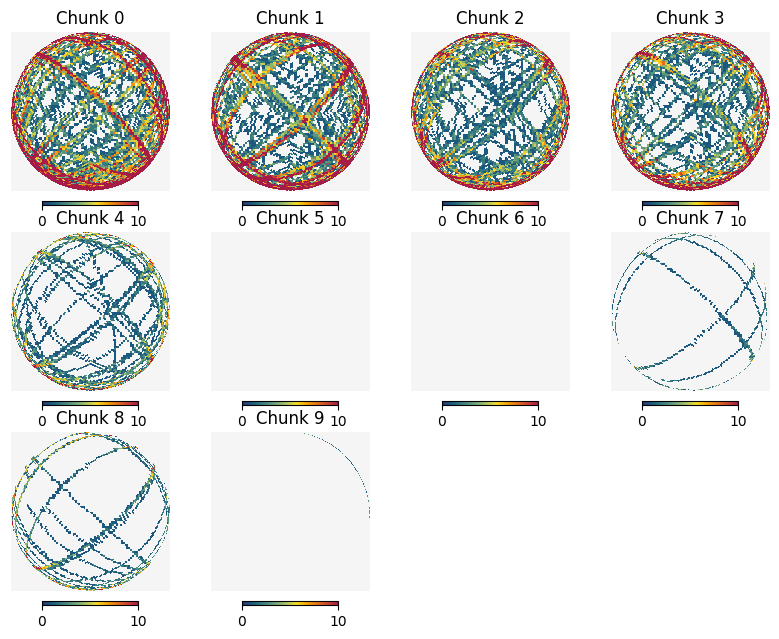

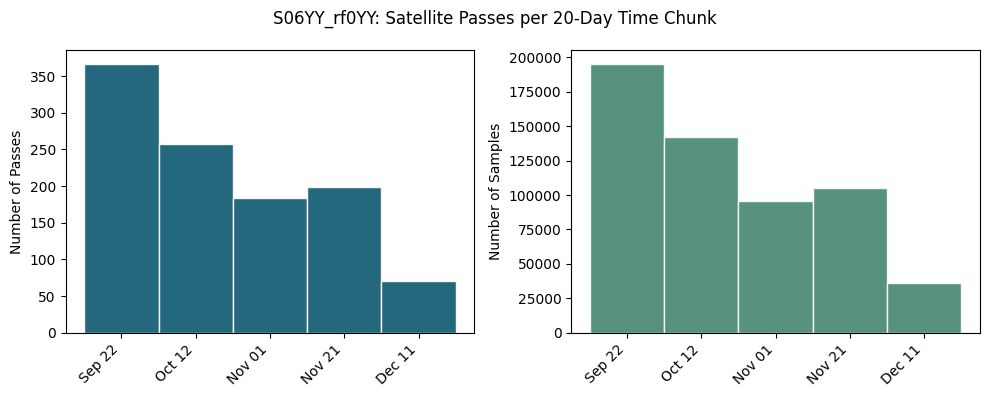

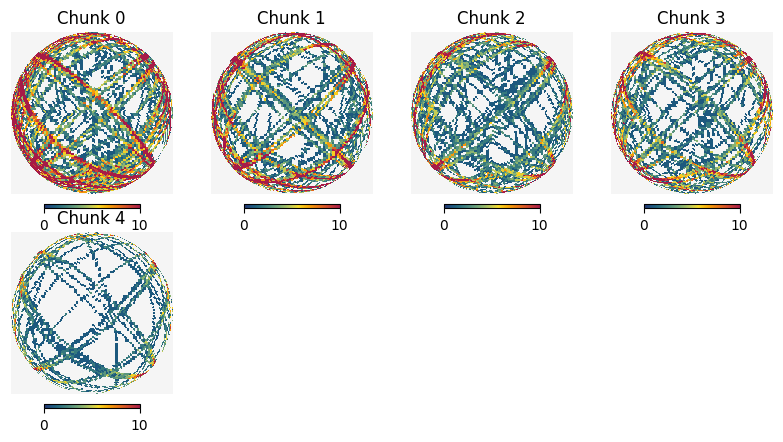

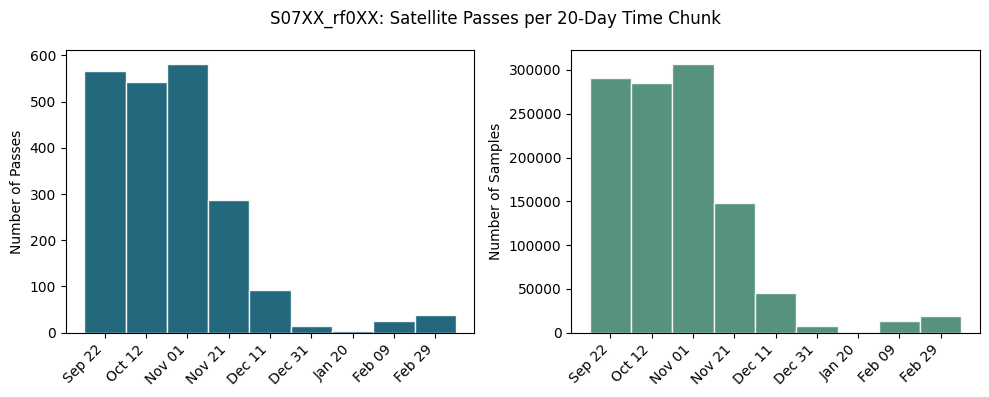

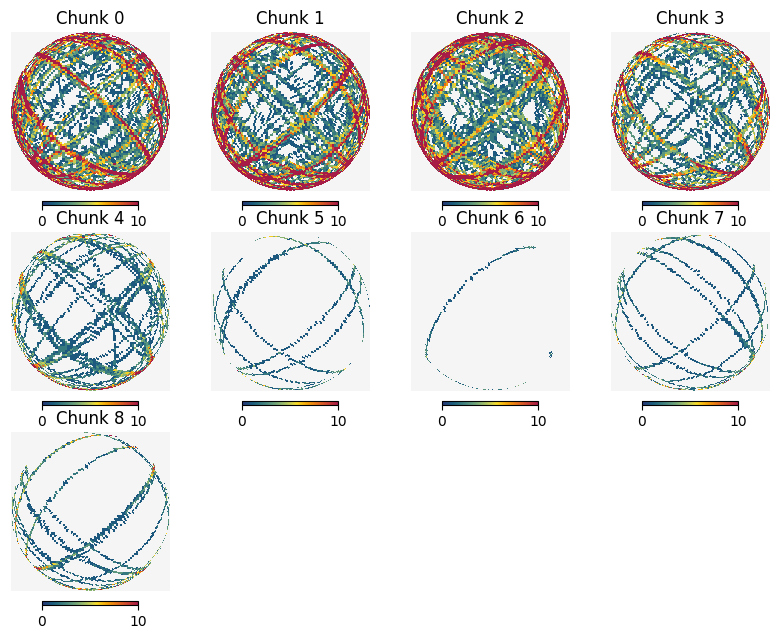

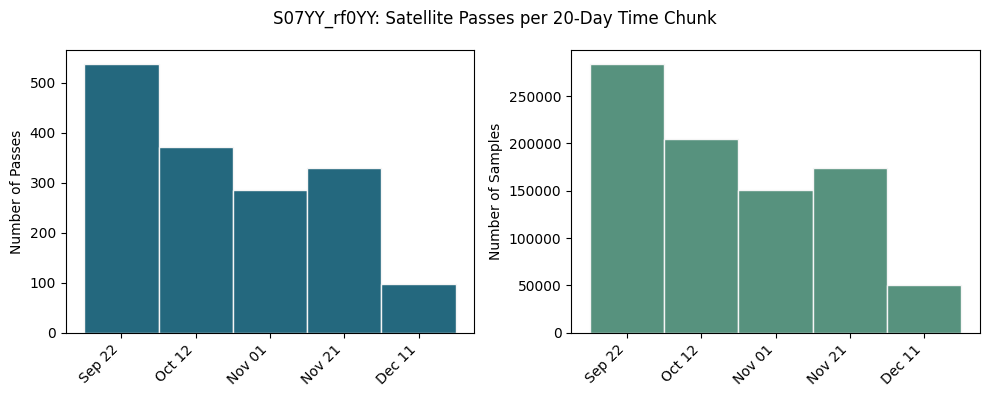

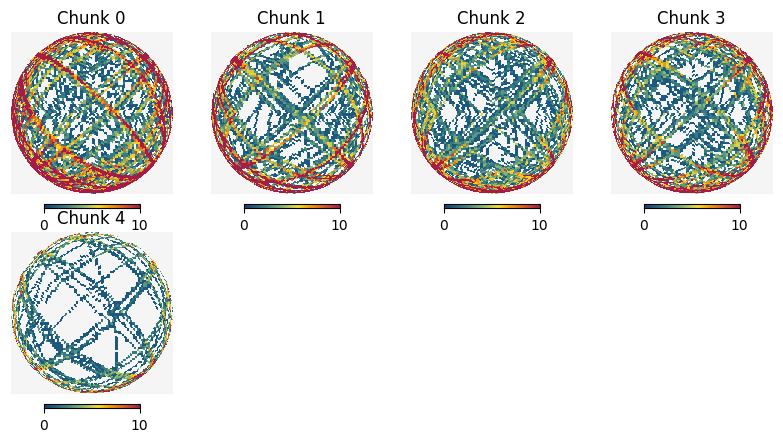

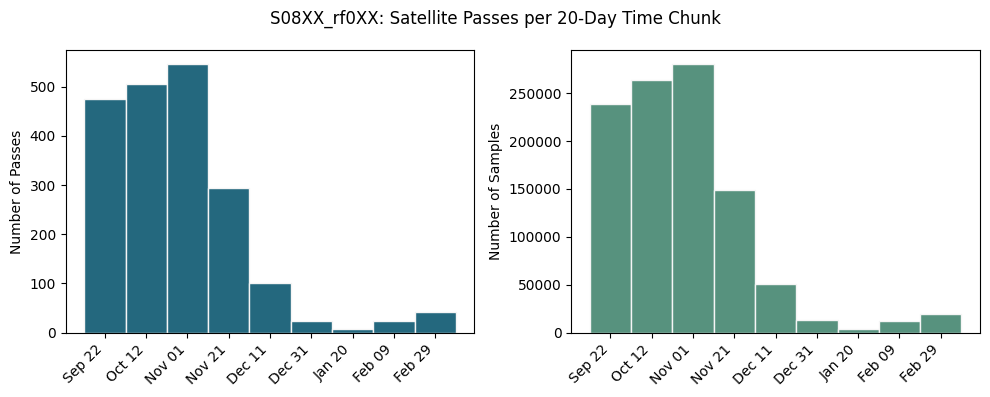

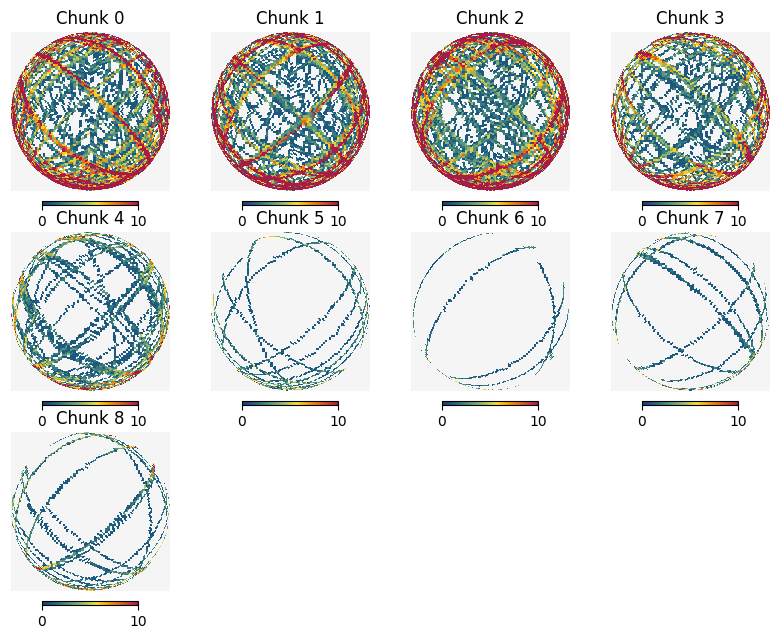

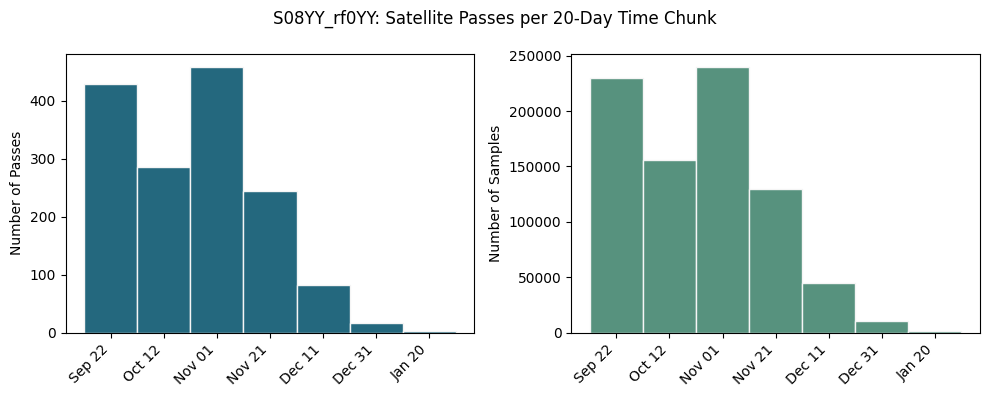

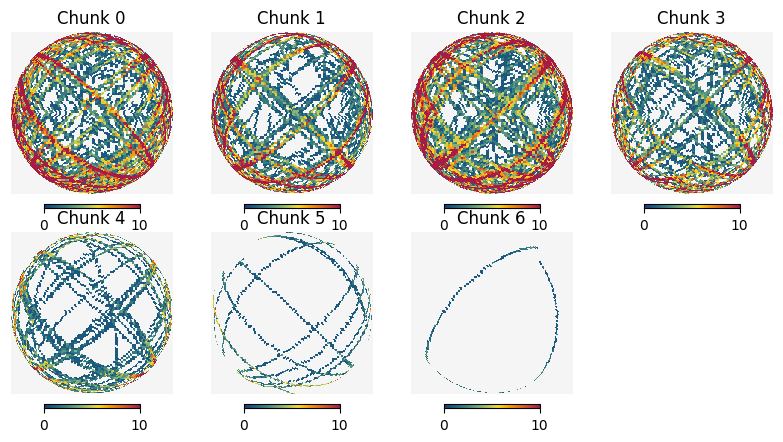

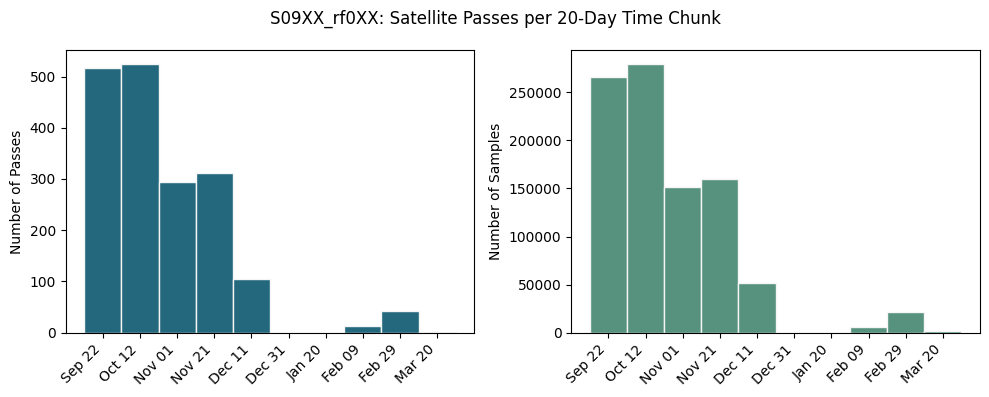

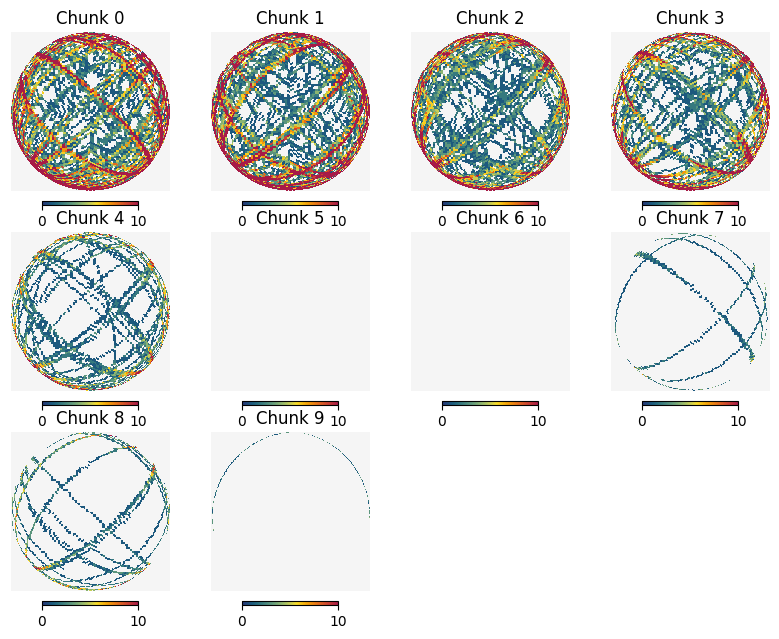

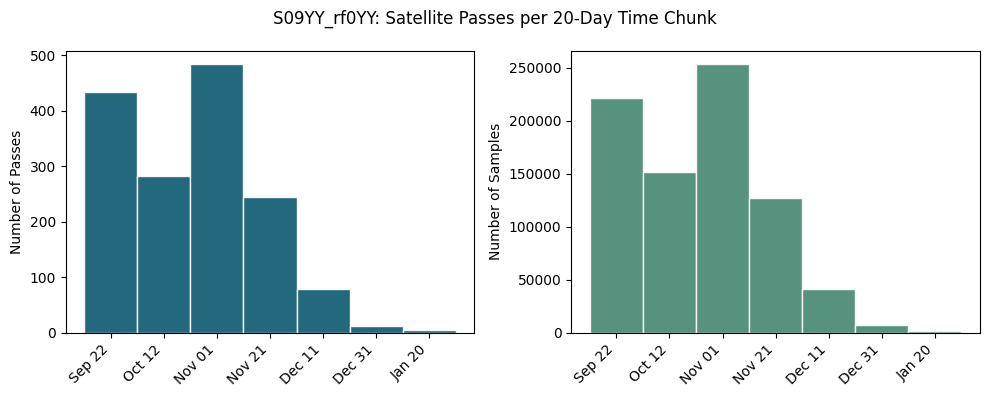

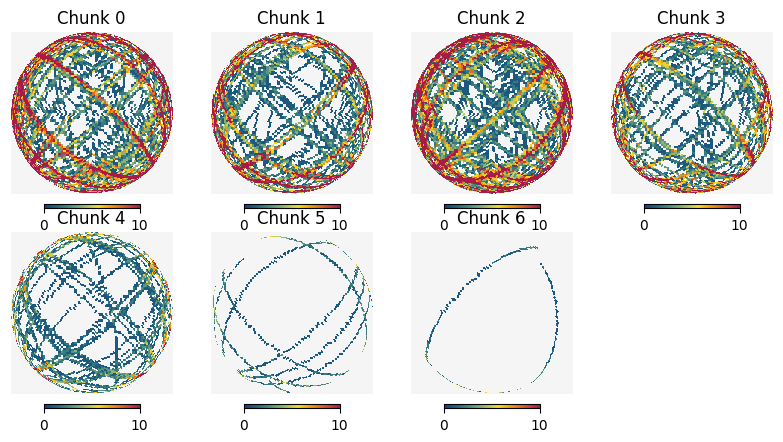

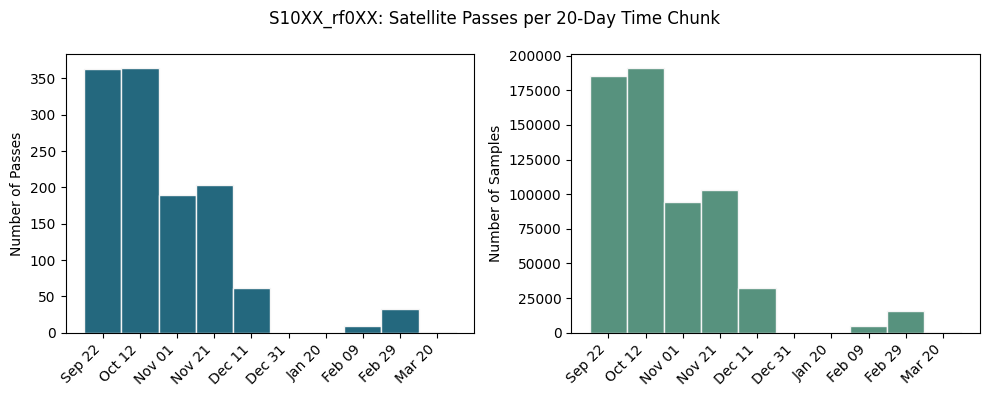

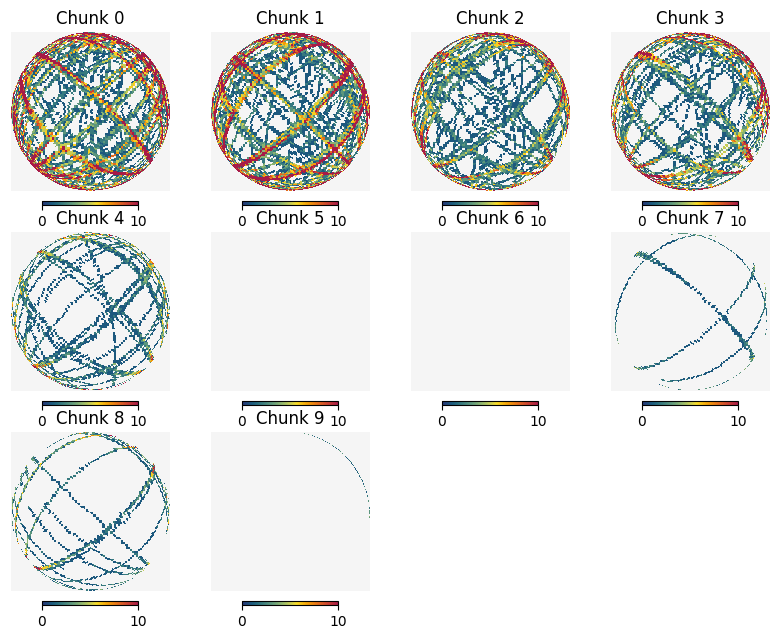

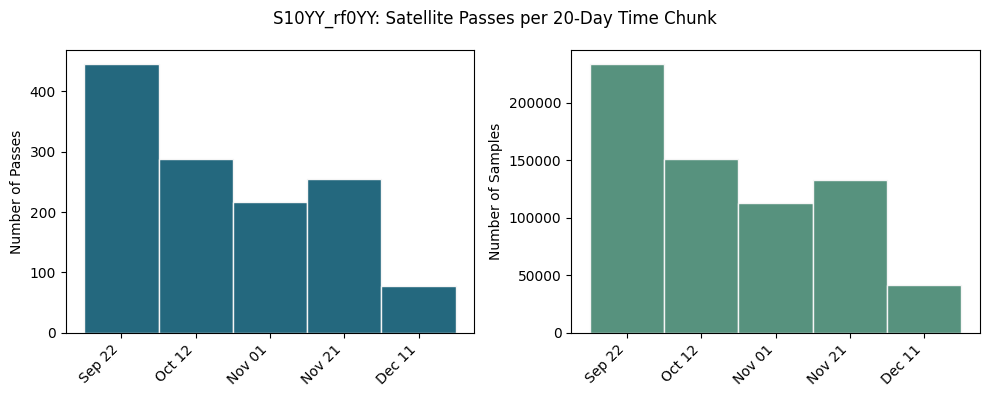

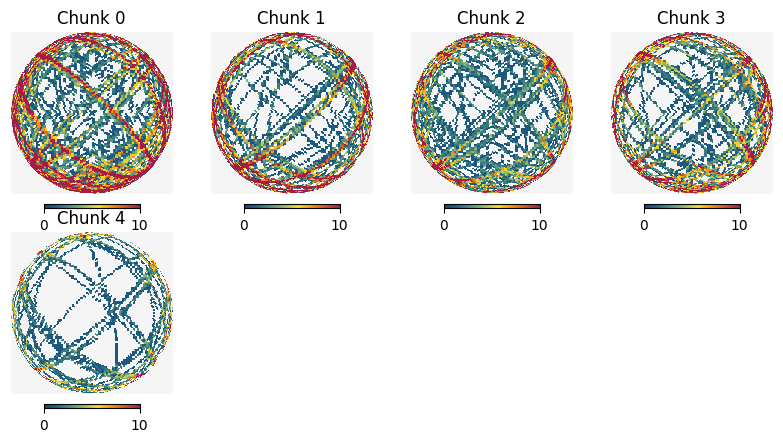

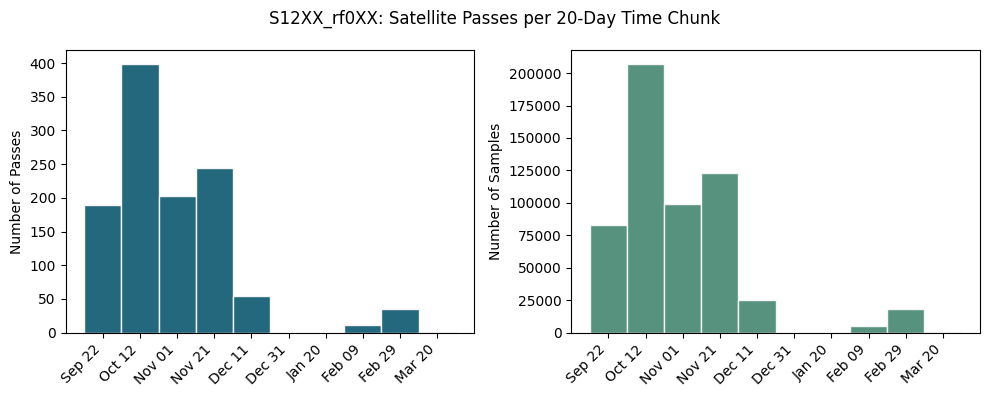

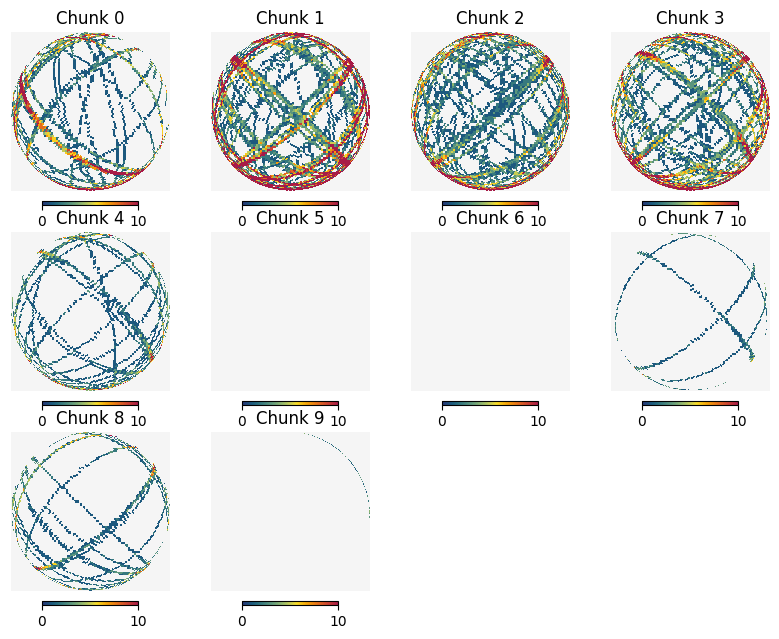

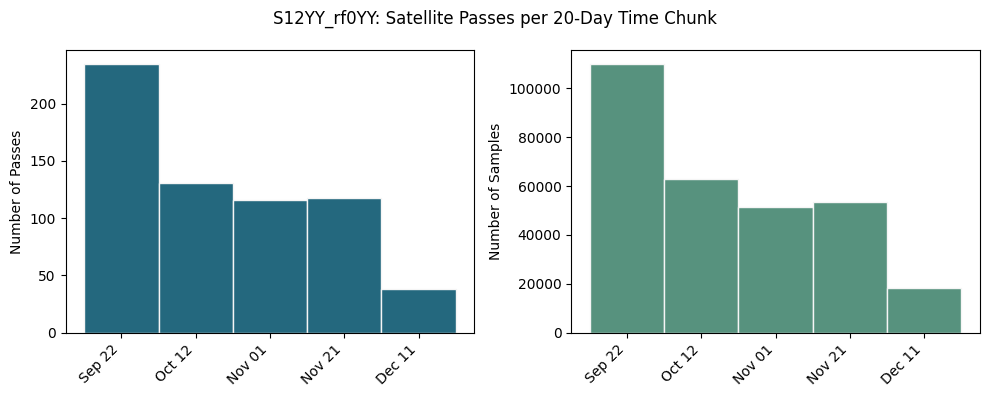

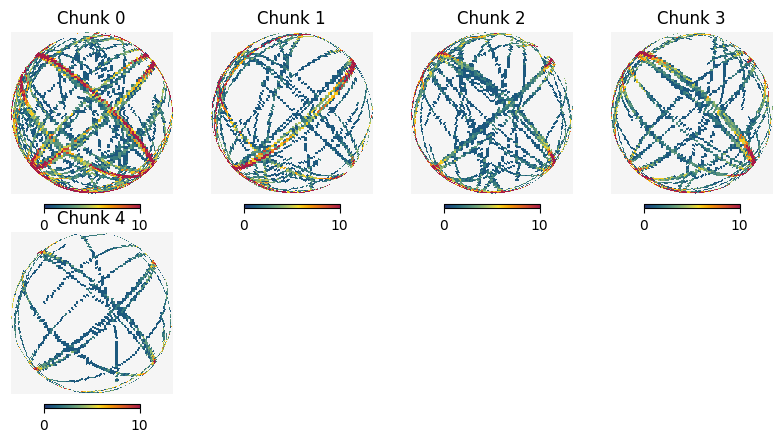

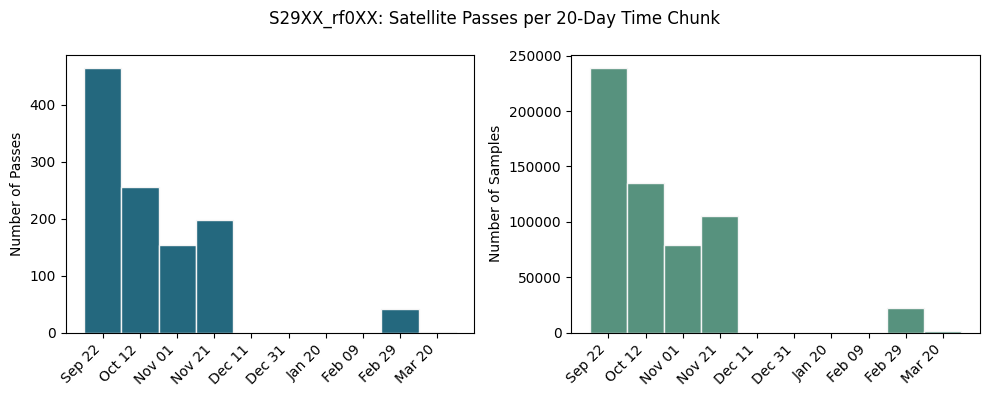

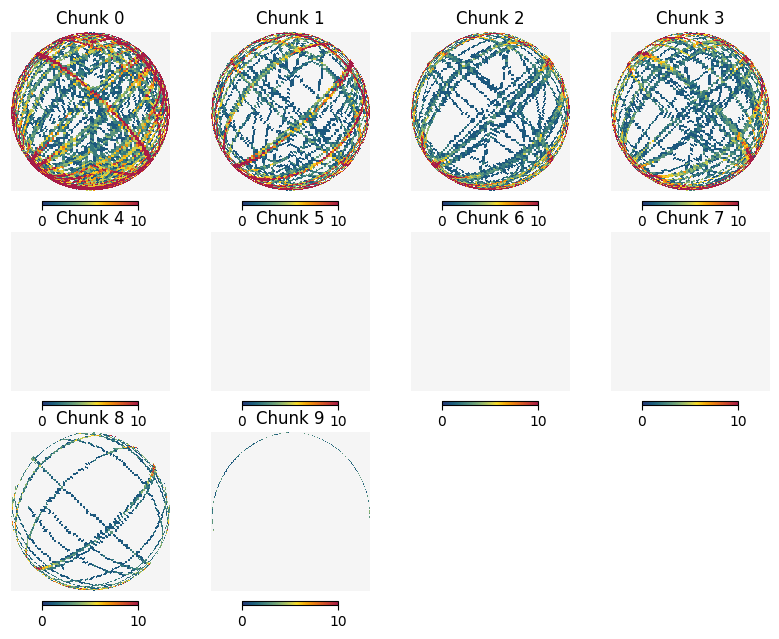

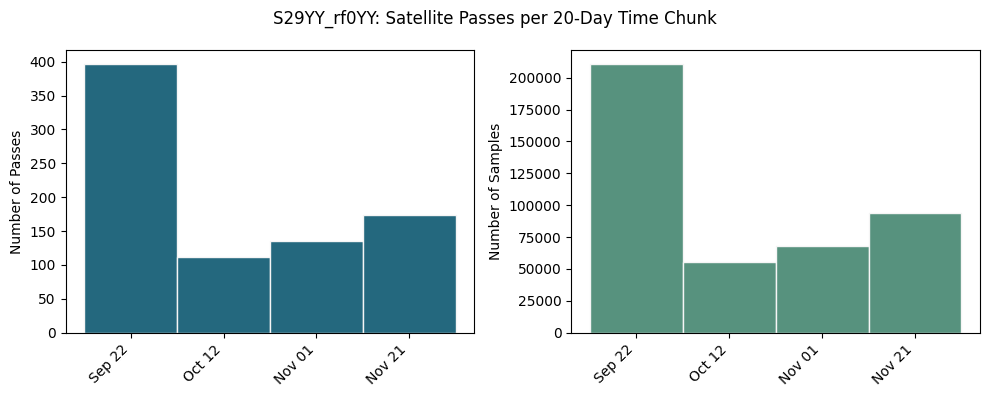

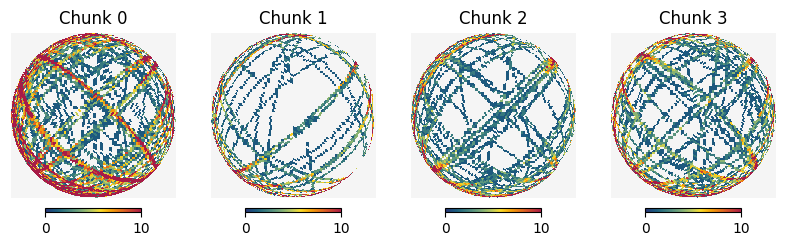

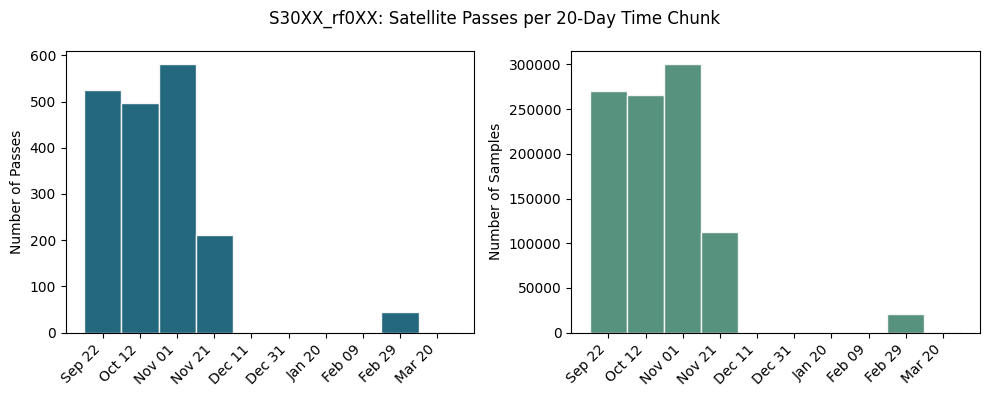

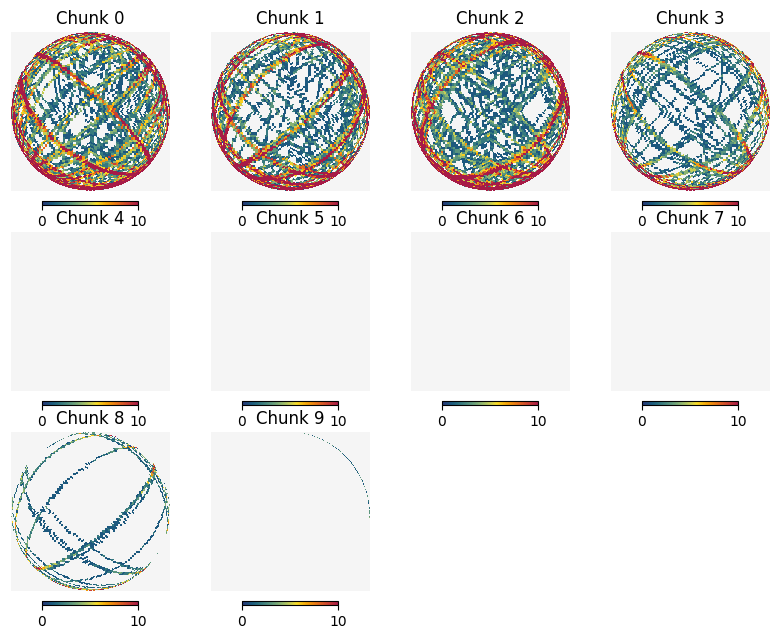

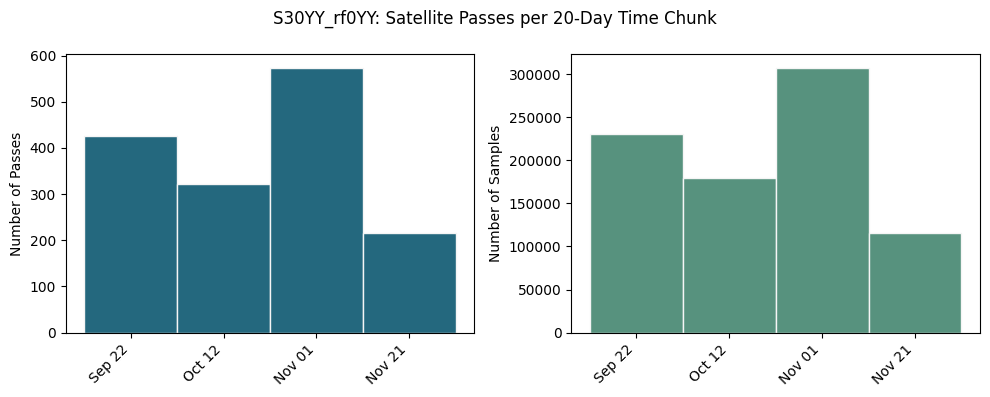

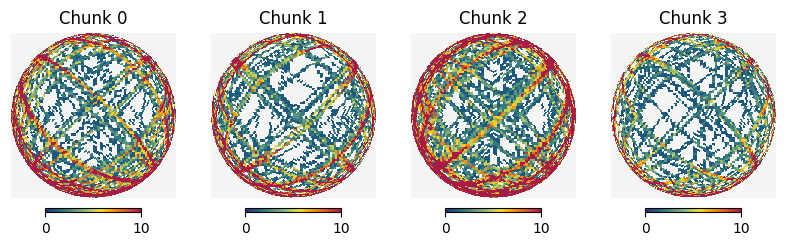

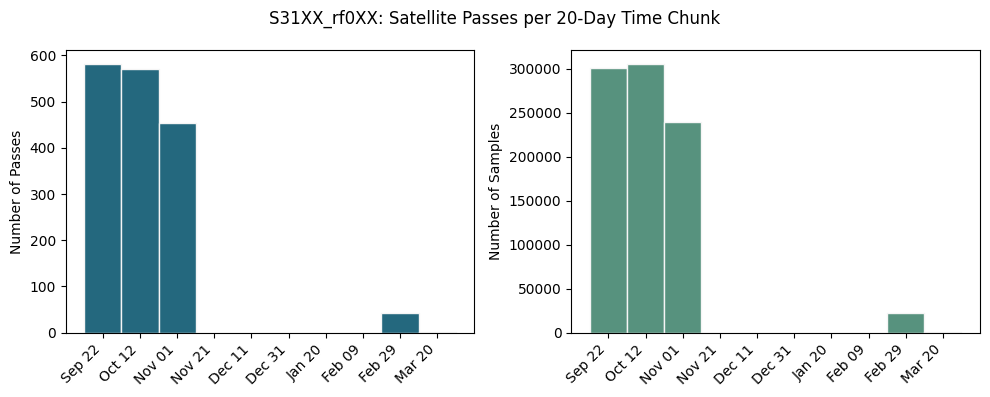

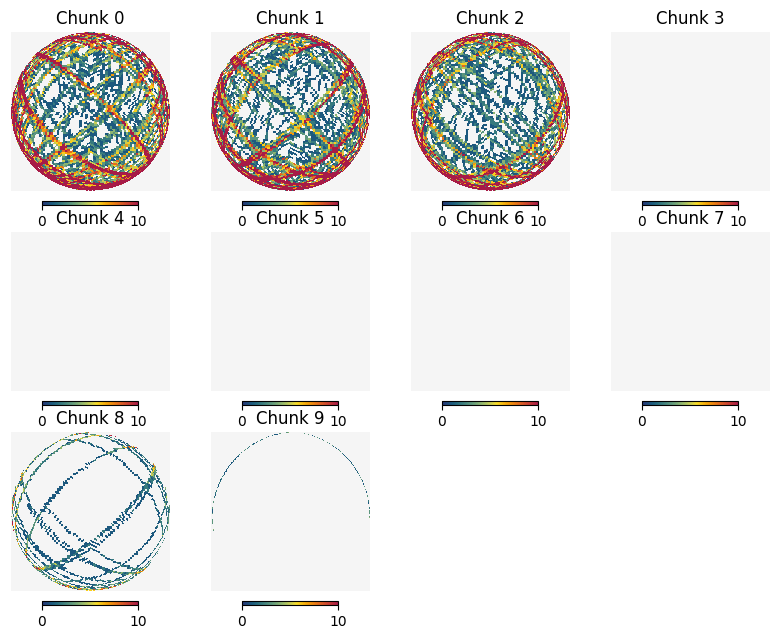

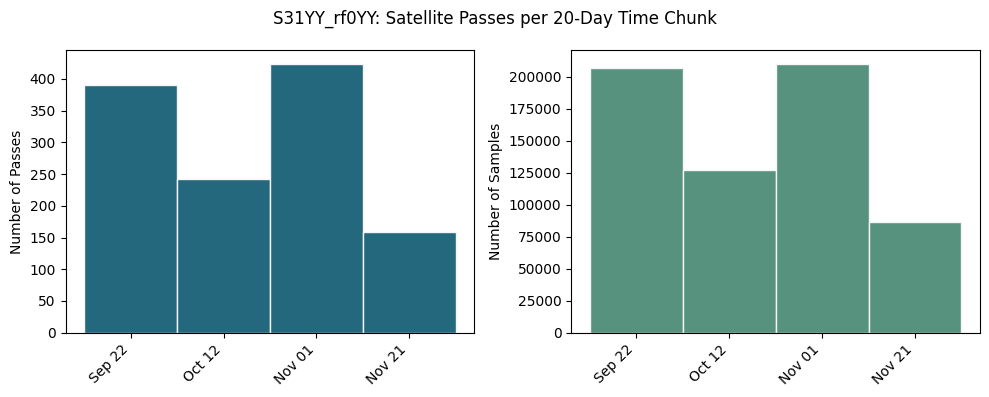

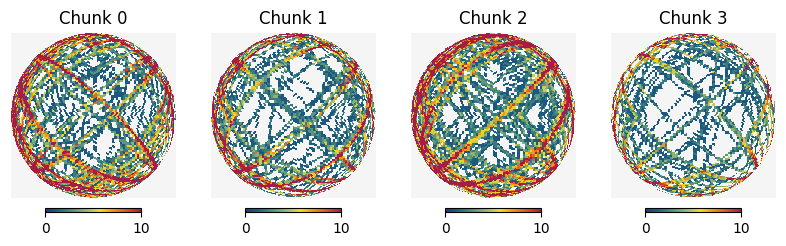

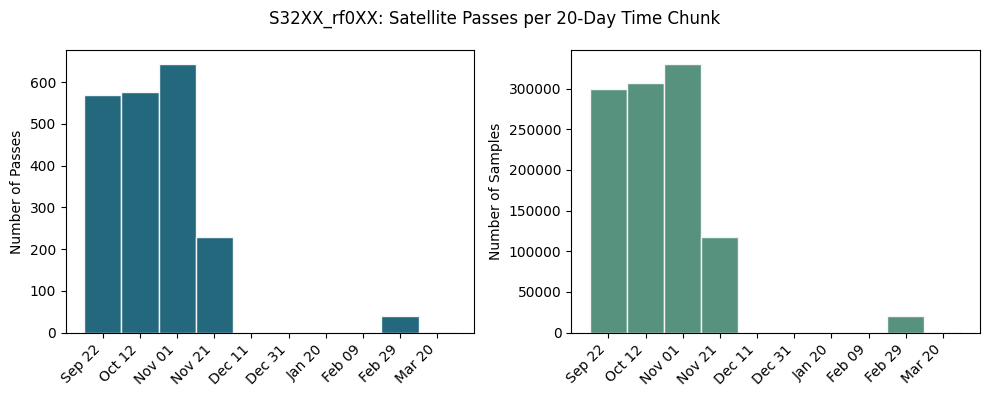

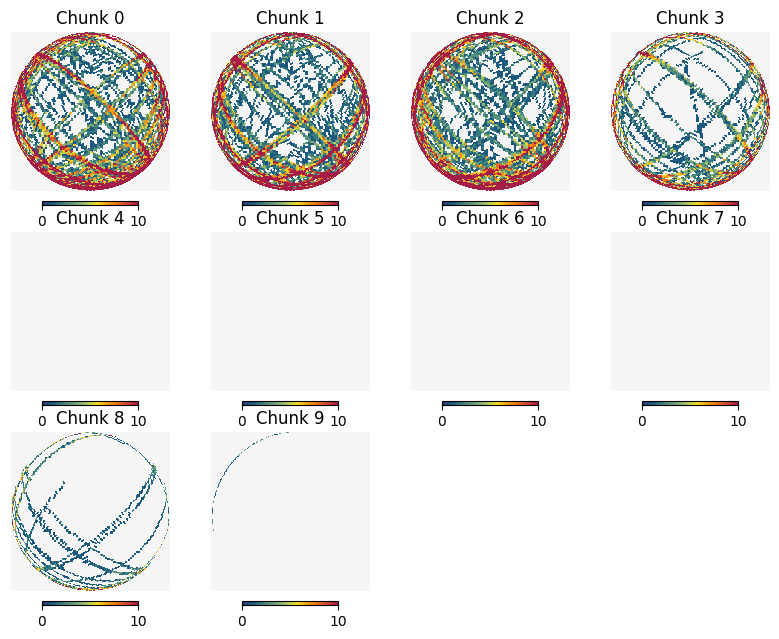

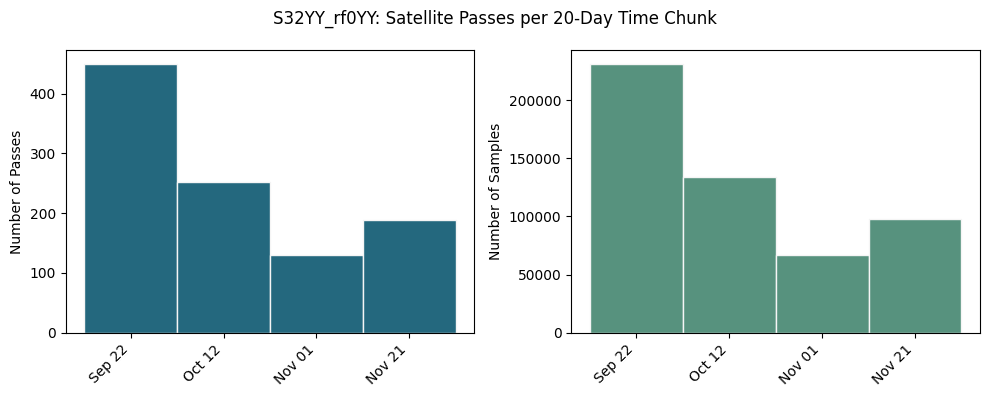

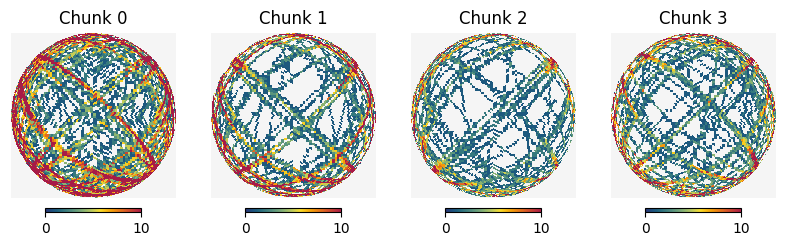

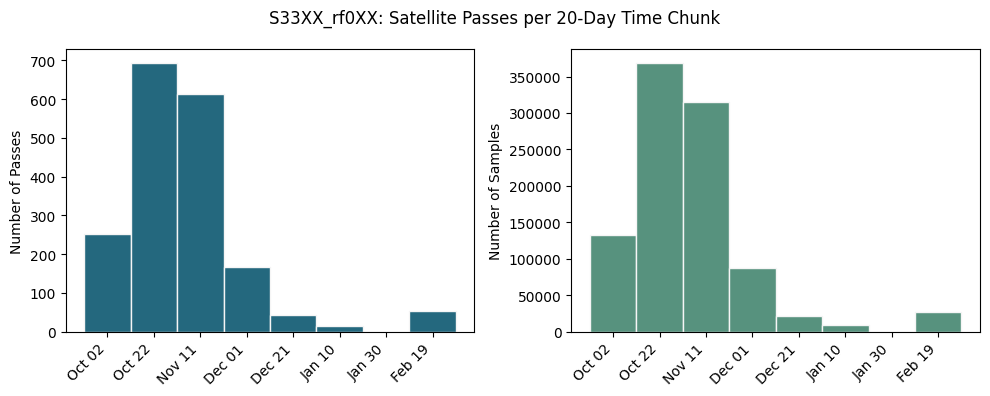

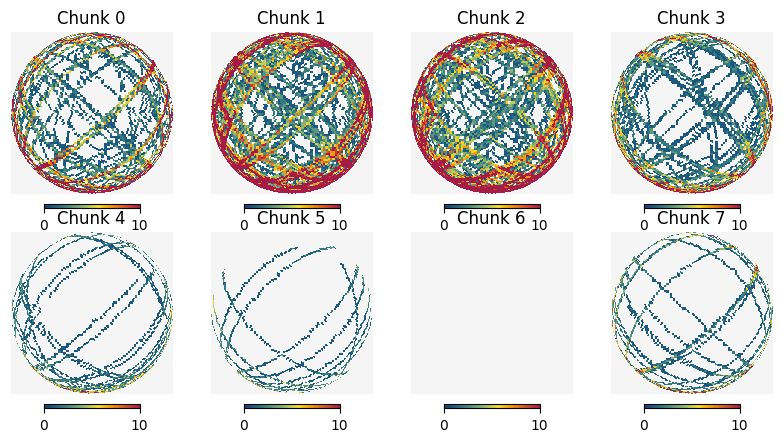

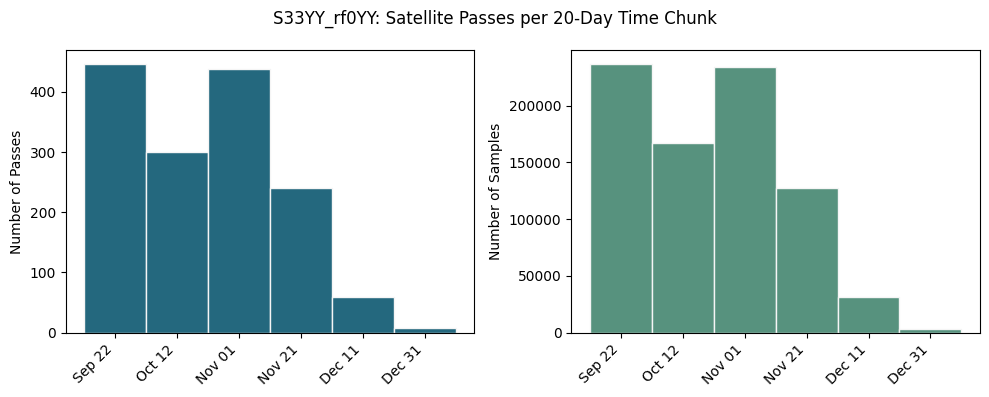

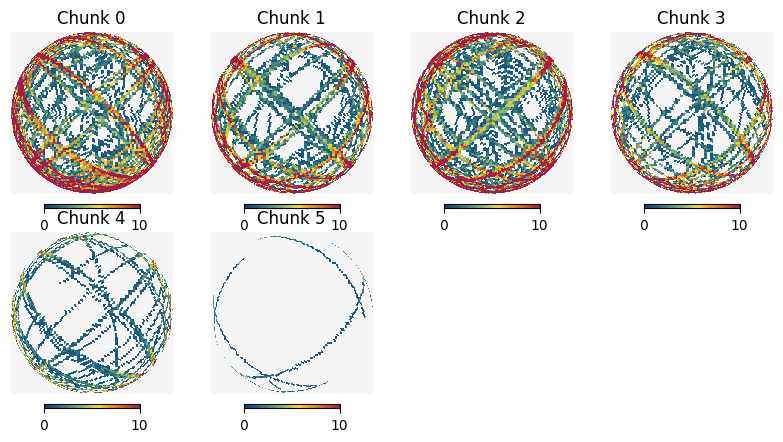

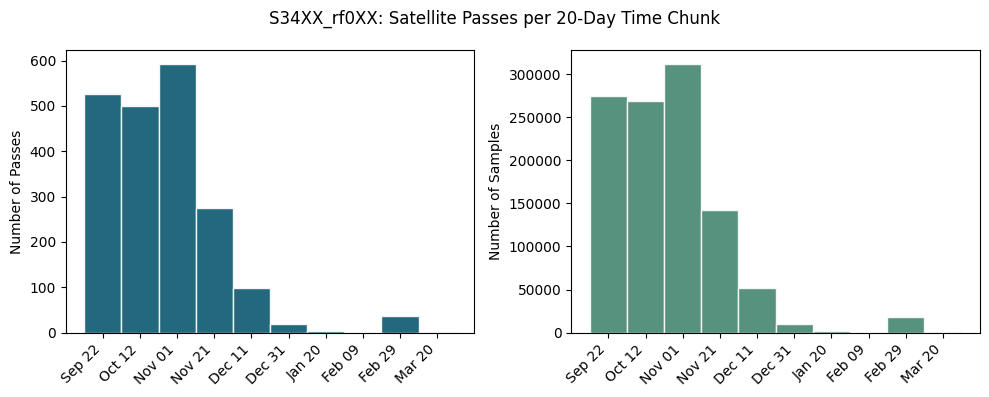

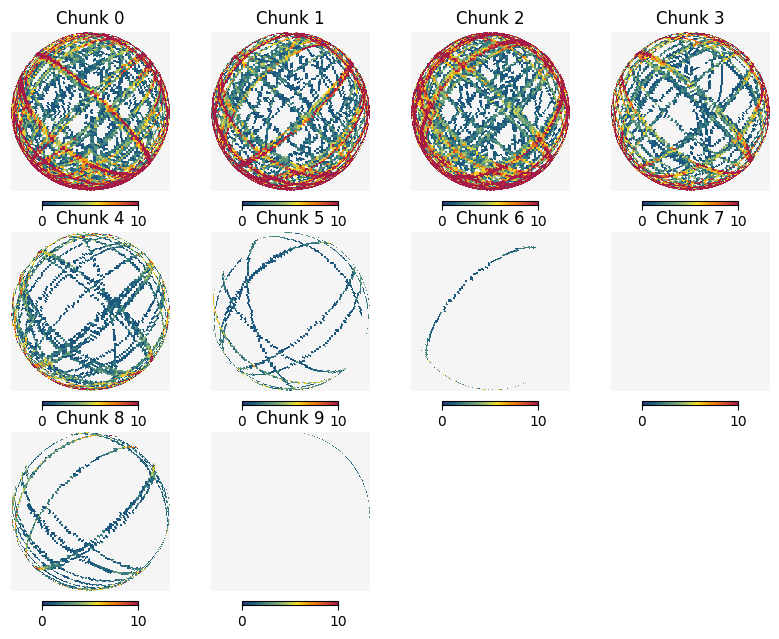

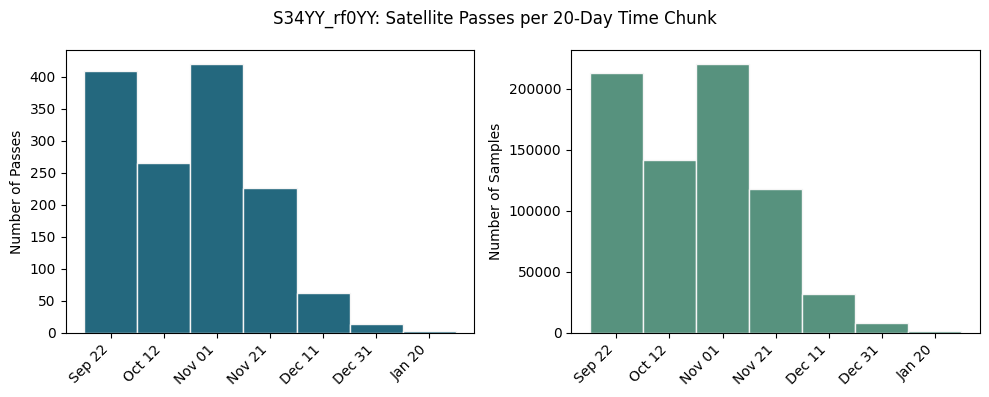

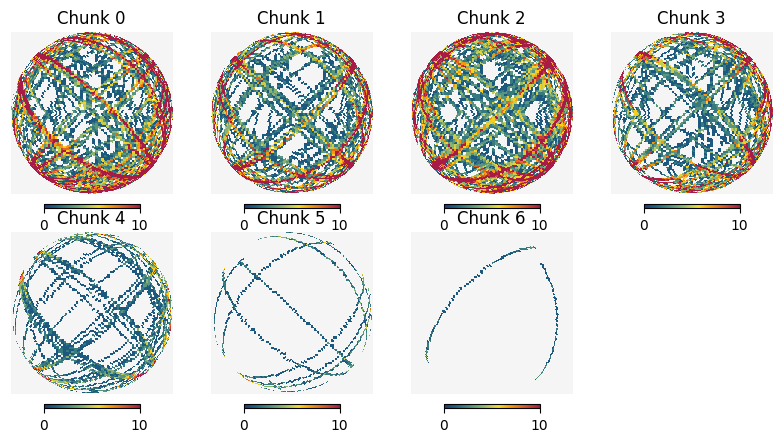

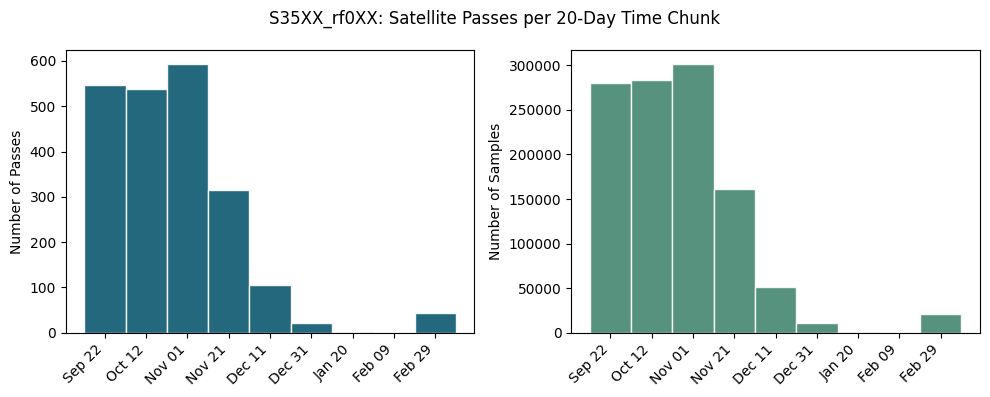

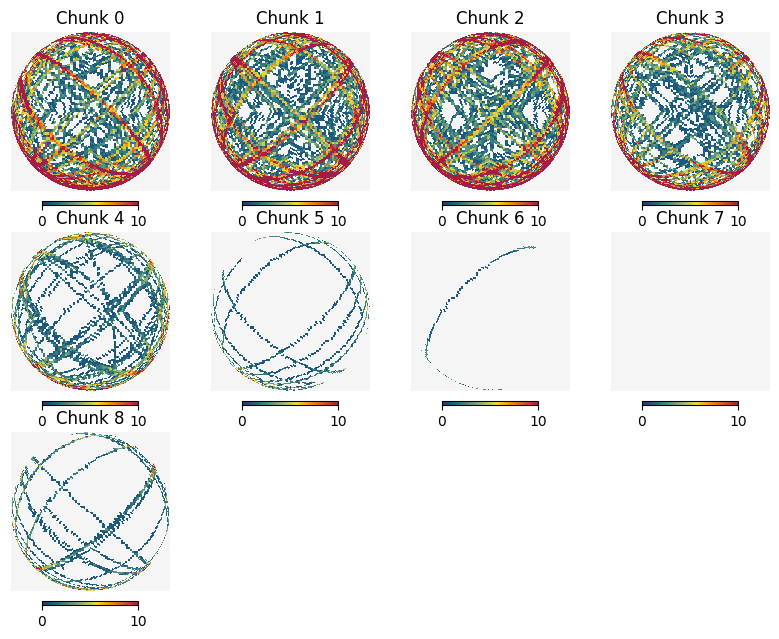

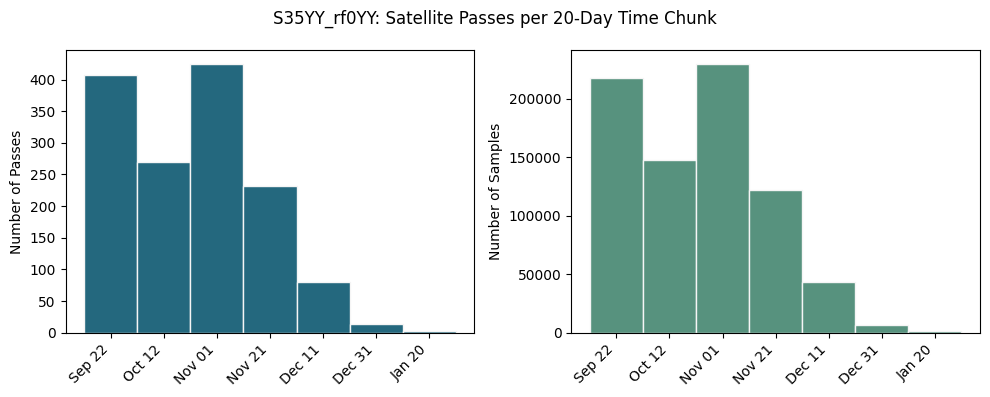

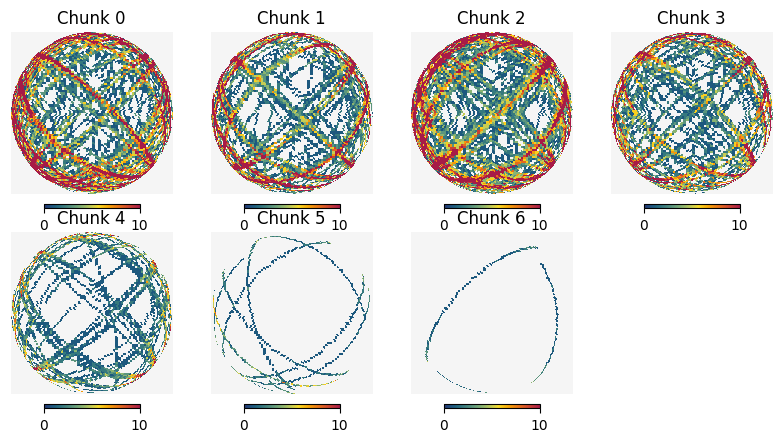

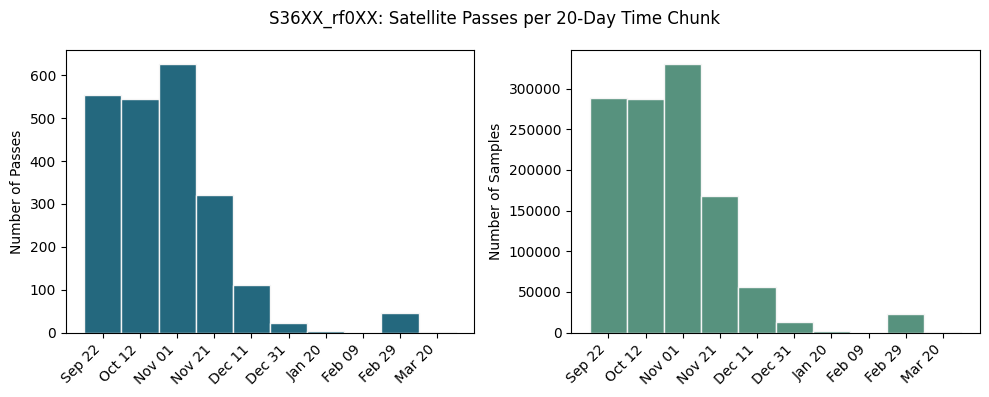

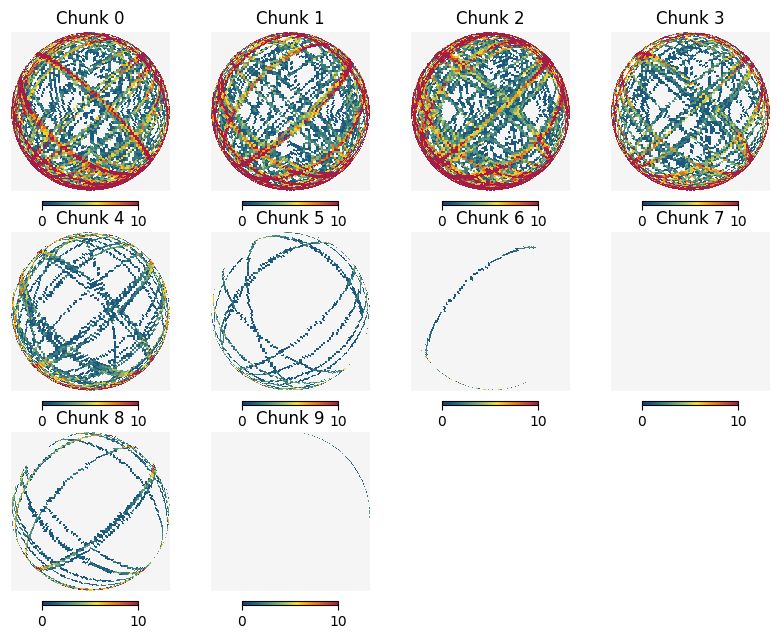

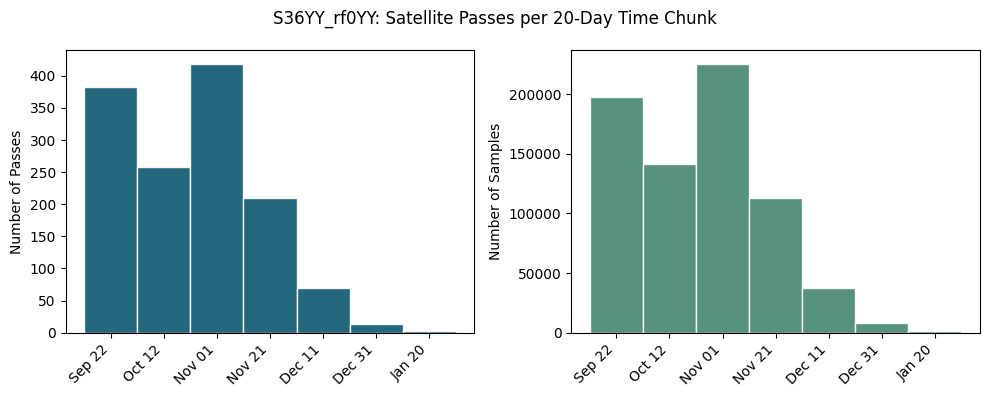

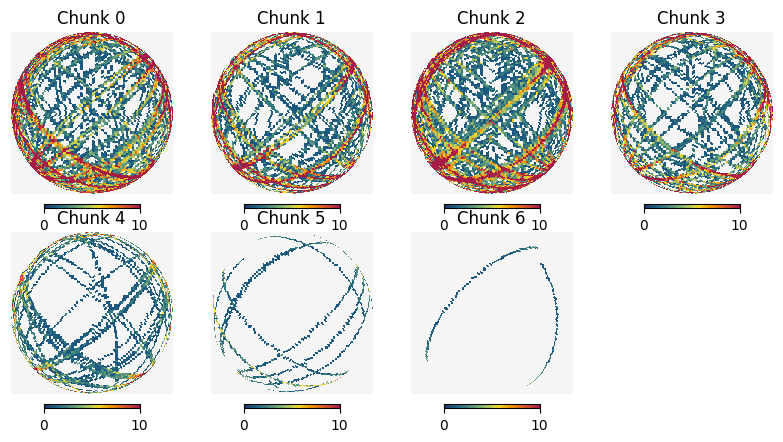

In [4]:
pfs = sorted(Path("../passes/monotonic_concave_cal/rf0/").glob("*.h5"))

for p in pfs:
    pf = PassFile(p)
    passes = pf.read_passes(pointing=0)
    
    chunk_days = 20
    chunk_sec = chunk_days * 24 * 60 * 60
    chunks, bin_edges, bin_centers = chunk_passes(
        passes,
        chunk_sec=chunk_sec,
    )
    
    pass_counts = [len(chunk) for chunk in chunks]
    
    sample_counts = [0]*len(chunks)
    for i, chunk in enumerate(chunks):
        for cid in chunk:
            pass_n_samples = passes[cid].power_db.size
            sample_counts[i] += pass_n_samples
    
    # Convert Unix timestamps to UTC datetimes
    bin_center_dt = [
        datetime.fromtimestamp(t, tz=UTC)
        for t in bin_centers
    ]
    
    count_maps = chunks_to_healpix_counts(
        passes,
        chunks,
        decimate=5,
        flag_threshold_db=3.0,
        nside=32,
    )

    # Plot
    fig, ax = plt.subplots(1, 2, figsize=(10, 4))
    
    ax[0].bar(
        bin_center_dt,
        pass_counts,
        width=chunk_days,
        align="center",
        color=cmr.pride(0.2),
        ec="whitesmoke"
    )
    ax[0].set_ylabel("Number of Passes")
    
    ax[1].bar(
        bin_center_dt,
        sample_counts,
        width=chunk_days,
        align="center",
        color=cmr.pride(0.3),
        ec="whitesmoke"
    )
    ax[1].set_ylabel("Number of Samples")
    
    labels = [dt.strftime("%b %d") for dt in bin_center_dt]
    for a in ax:
        a.set_xticks(bin_center_dt)
        a.set_xticklabels(labels, rotation=45, ha="right")

    fig.suptitle(f"{p.stem[:11]}: Satellite Passes per {chunk_days}-Day Time Chunk")
    
    plt.tight_layout()
    plt.show()

    ncols = 4
    nrows = np.ceil(len(count_maps) / ncols)
    
    fig = plt.figure(figsize=(2 * ncols, 2 * nrows))
    
    for i, count_map in enumerate(count_maps):
        hp.orthview(
            count_map,
            fig=fig.number,
            sub=(nrows, ncols, i + 1),
            title=f"Chunk {i}",
            min=0,
            max=10,
            cmap=prd,
            cbar=True,
            half_sky=True,
            rot=(0, 90, 180)
        )
    
    plt.show()